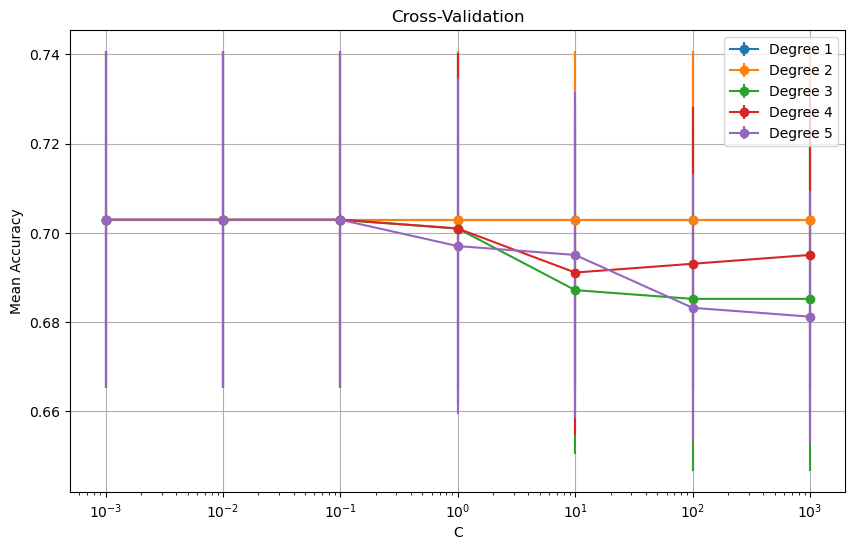

Best Polynomial Degree: 1
Best C: 0.001


In [1]:
#Header for dataset 1: # id:23-23-23-1
#Header for dataset 2: # id:23--23-23-1


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve, auc


dataset = pd.read_csv('dataset_1.csv', header=None, names=['X_1', 'X_2', 'Target'])
X = dataset[['X_1', 'X_2']].values
y = dataset['Target'].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = [1, 2, 3, 4, 5]
C_values = np.logspace(-3, 3, 7)

results = {'degree': [], 'C': [], 'mean_accuracy': [], 'std_accuracy': []}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    for C in C_values:
        accuracy_scores = []
        
        for train_index, test_index in kf.split(X_poly):
            X_train_cv, X_test_cv = X_poly[train_index], X_poly[test_index]
            y_train_cv, y_test_cv = y[train_index], y[test_index]
            
            model = LogisticRegression(penalty='l2', C=C, max_iter=10000)
            model.fit(X_train_cv, y_train_cv)
            
            y_pred_cv = model.predict(X_test_cv)
            accuracy_scores.append(accuracy_score(y_test_cv, y_pred_cv))
        
        results['degree'].append(degree)
        results['C'].append(C)
        results['mean_accuracy'].append(np.mean(accuracy_scores))
        results['std_accuracy'].append(np.std(accuracy_scores))

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
for degree in degrees:
    subset = results_df[results_df['degree'] == degree]
    plt.errorbar(subset['C'], subset['mean_accuracy'], yerr=subset['std_accuracy'], label=f'Degree {degree}', marker='o')

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validation')
plt.legend()
plt.grid(True)
plt.show()

best_index = np.argmax(results_df['mean_accuracy'])
best_degree = results_df.loc[best_index, 'degree']
best_C = results_df.loc[best_index, 'C']

print(f'Best Polynomial Degree: {best_degree}')
print(f'Best C: {best_C}')


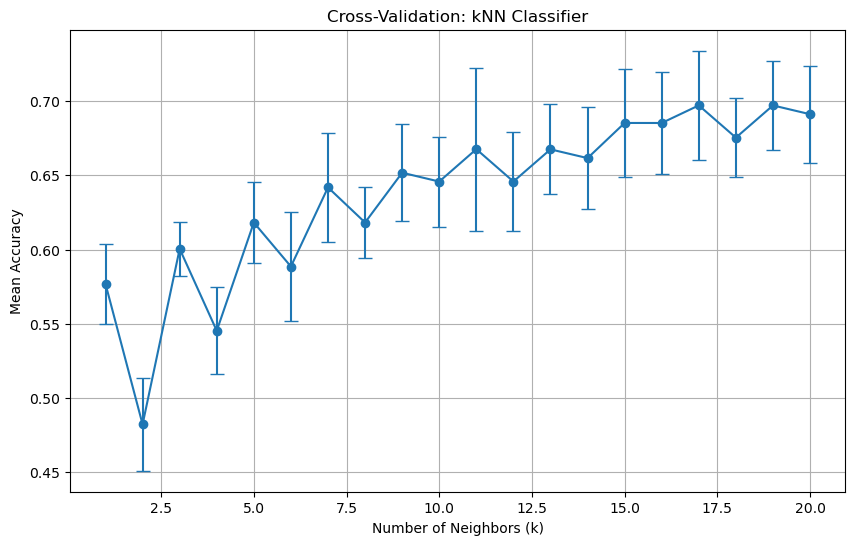

Best k: 17
Highest Cross-validation Accuracy for kNN: 0.6970


KNeighborsClassifier(n_neighbors=17)

In [2]:
k_values = range(1, 21)

results_knn = {'k': [], 'mean_accuracy': [], 'std_accuracy': []}

warnings.filterwarnings("ignore", category=FutureWarning)

for k in k_values:
    accuracy_scores = []
    
    for train_index, test_index in kf.split(X):
        X_train_cv, X_test_cv = X[train_index], X[test_index]
        y_train_cv, y_test_cv = y[train_index], y[test_index]
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_cv, y_train_cv)
        
        y_pred_cv = knn.predict(X_test_cv)
        accuracy_scores.append(accuracy_score(y_test_cv, y_pred_cv))
    
    results_knn['k'].append(k)
    results_knn['mean_accuracy'].append(np.mean(accuracy_scores))
    results_knn['std_accuracy'].append(np.std(accuracy_scores))

results_knn_df = pd.DataFrame(results_knn)

plt.figure(figsize=(10, 6))
plt.errorbar(results_knn_df['k'], results_knn_df['mean_accuracy'], yerr=results_knn_df['std_accuracy'], marker='o', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validation: kNN Classifier')
plt.grid(True)
plt.show()

best_k_index = np.argmax(results_knn_df['mean_accuracy'])
best_k = results_knn_df.loc[best_k_index, 'k']
best_accuracy_knn = results_knn_df.loc[best_k_index, 'mean_accuracy']

print(f'Best k: {best_k}')
print(f'Highest Cross-validation Accuracy for kNN: {best_accuracy_knn:.4f}')

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X, y)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Training the kNN model with k=17
final_knn = KNeighborsClassifier(n_neighbors=17)
final_knn.fit(X_train, y_train)

test_accuracy_knn = final_knn.score(X_test, y_test)
print(f"Test Accuracy for kNN (k=17): {test_accuracy_knn:.4f}")


Test Accuracy for kNN (k=17): 0.6863


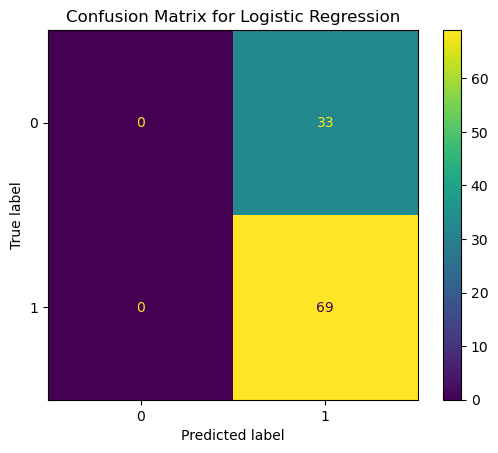

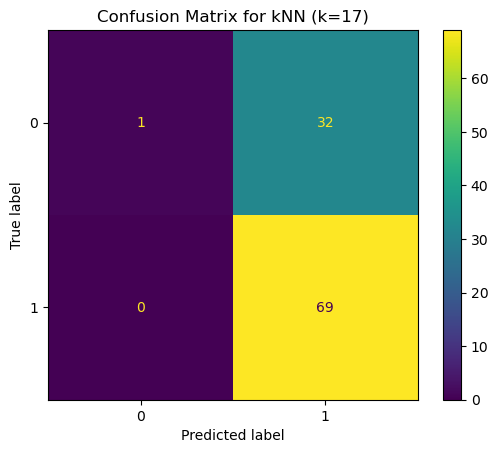

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_degree = 1
best_C = 0.001
poly = PolynomialFeatures(degree=best_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

log_reg = LogisticRegression(penalty='l2', C=best_C, max_iter=10000)
log_reg.fit(X_poly_train, y_train)
y_log_reg_pred = log_reg.predict(X_poly_test)

cm_log_reg = confusion_matrix(y_test, y_log_reg_pred)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot()
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

k = 17
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_knn_pred = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title(f'Confusion Matrix for kNN (k={k})')
plt.show()

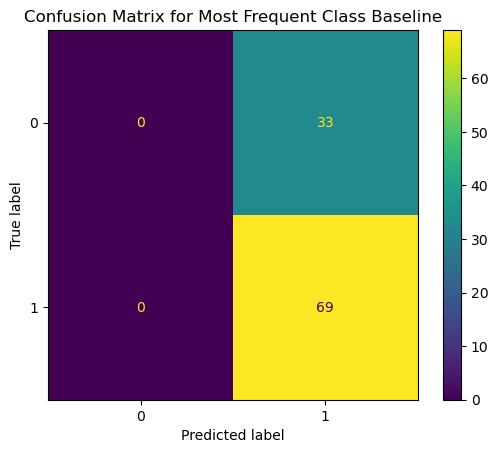

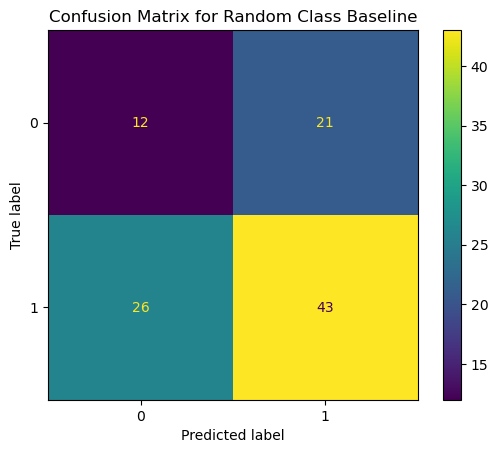

In [6]:
dummy_most_frequent = DummyClassifier(strategy="most_frequent")
dummy_most_frequent.fit(X_train, y_train)
y_dummy_mf_pred = dummy_most_frequent.predict(X_test)

cm_dummy_mf = confusion_matrix(y_test, y_dummy_mf_pred)
disp_dummy_mf = ConfusionMatrixDisplay(confusion_matrix=cm_dummy_mf)
disp_dummy_mf.plot()
plt.title('Confusion Matrix for Most Frequent Class Baseline')
plt.show()

dummy_random = DummyClassifier(strategy="uniform")
dummy_random.fit(X_train, y_train)
y_dummy_random_pred = dummy_random.predict(X_test)

cm_dummy_random = confusion_matrix(y_test, y_dummy_random_pred)
disp_dummy_random = ConfusionMatrixDisplay(confusion_matrix=cm_dummy_random)
disp_dummy_random.plot()
plt.title('Confusion Matrix for Random Class Baseline')
plt.show()

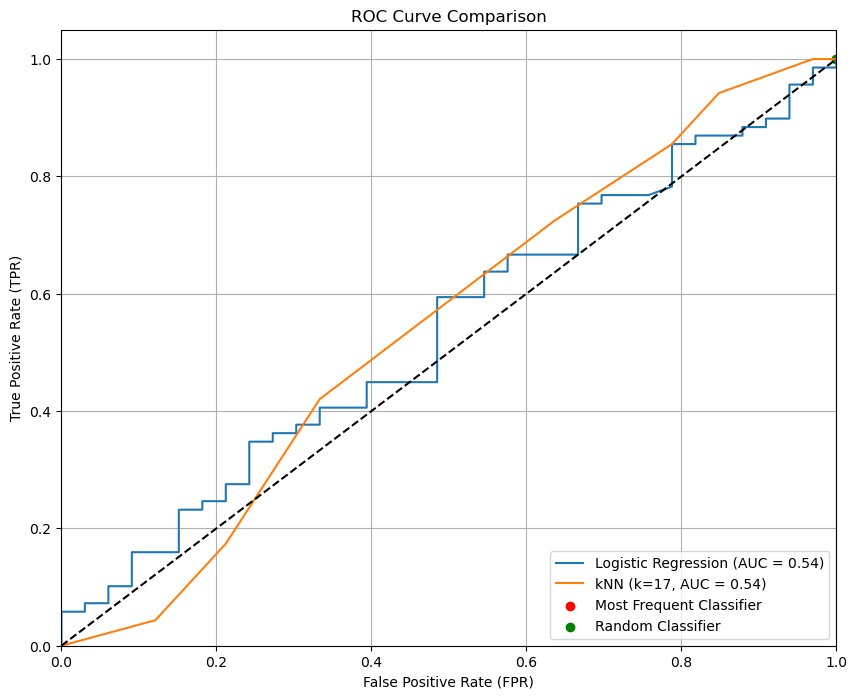

In [7]:
best_degree = 1
best_C = 0.001
poly = PolynomialFeatures(degree=best_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

log_reg = LogisticRegression(penalty='l2', C=best_C, max_iter=10000)
log_reg.fit(X_poly_train, y_train)

y_log_reg_probs = log_reg.predict_proba(X_poly_test)[:, 1]

k = 17
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_knn_probs = knn.predict_proba(X_test)[:, 1]

dummy_most_frequent = DummyClassifier(strategy="most_frequent")
dummy_most_frequent.fit(X_train, y_train)
y_dummy_mf_probs = dummy_most_frequent.predict_proba(X_test)[:, 1]

dummy_random = DummyClassifier(strategy="uniform")
dummy_random.fit(X_train, y_train)
y_dummy_random_probs = dummy_random.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 8))

fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_log_reg_probs)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_probs)
roc_auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f'kNN (k={k}, AUC = {roc_auc_knn:.2f})')

fpr_dummy_mf, tpr_dummy_mf, _ = roc_curve(y_test, y_dummy_mf_probs)
plt.scatter(fpr_dummy_mf[1], tpr_dummy_mf[1], color='red', label='Most Frequent Classifier')

fpr_dummy_random, tpr_dummy_random, _ = roc_curve(y_test, y_dummy_random_probs)
plt.scatter(fpr_dummy_random[1], tpr_dummy_random[1], color='green', label='Random Classifier')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

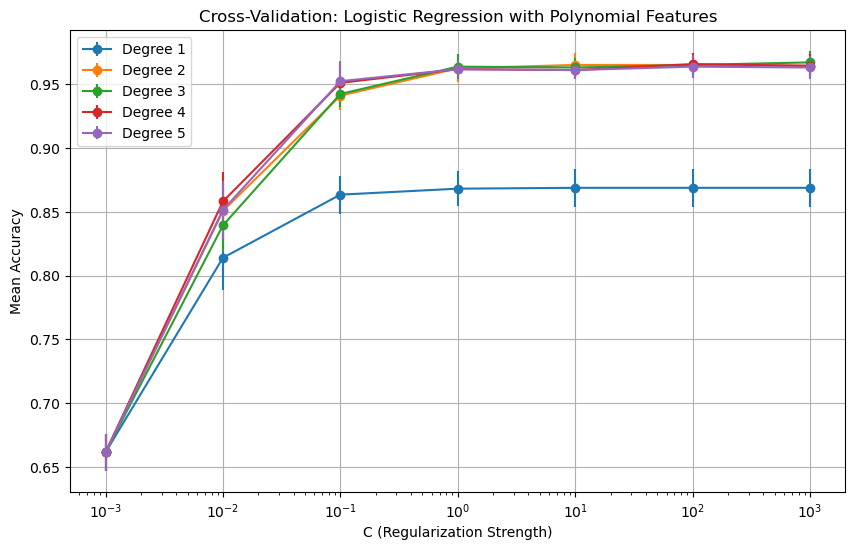

Best Polynomial Degree: 3
Best Regularization Strength (C): 1000.0


In [8]:
# Load dataset
dataset = pd.read_csv('dataset_2.csv', header=None, names=['Feature1', 'Feature2', 'Target'])
X = dataset[['Feature1', 'Feature2']].values
y = dataset['Target'].values

# Split the dataset
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameters to test
degrees = [1, 2, 3, 4, 5]
C_values = np.logspace(-3, 3, 7)

# Store results
results = {'degree': [], 'C': [], 'mean_accuracy': [], 'std_accuracy': []}

# Loop over each degree and C value
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    
    for C in C_values:
        accuracy_scores = []
        
        for train_index, test_index in kf.split(X_poly):
            X_train_cv, X_test_cv = X_poly[train_index], X_poly[test_index]
            y_train_cv, y_test_cv = y[train_index], y[test_index]
            
            model = LogisticRegression(penalty='l2', C=C, max_iter=10000)
            model.fit(X_train_cv, y_train_cv)
            
            y_pred_cv = model.predict(X_test_cv)
            accuracy_scores.append(accuracy_score(y_test_cv, y_pred_cv))
        
        # Store mean and standard deviation of cross-validation accuracy
        results['degree'].append(degree)
        results['C'].append(C)
        results['mean_accuracy'].append(np.mean(accuracy_scores))
        results['std_accuracy'].append(np.std(accuracy_scores))

# Convert to DataFrame for plotting
results_df = pd.DataFrame(results)

# Plot the cross-validation results with error bars
plt.figure(figsize=(10, 6))
for degree in degrees:
    subset = results_df[results_df['degree'] == degree]
    plt.errorbar(subset['C'], subset['mean_accuracy'], yerr=subset['std_accuracy'], label=f'Degree {degree}', marker='o')

plt.xscale('log')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validation: Logistic Regression with Polynomial Features')
plt.legend()
plt.grid(True)
plt.show()

# Find the best model parameters based on cross-validation accuracy
best_index = np.argmax(results_df['mean_accuracy'])
best_degree = results_df.loc[best_index, 'degree']
best_C = results_df.loc[best_index, 'C']

print(f'Best Polynomial Degree: {best_degree}')
print(f'Best Regularization Strength (C): {best_C}')


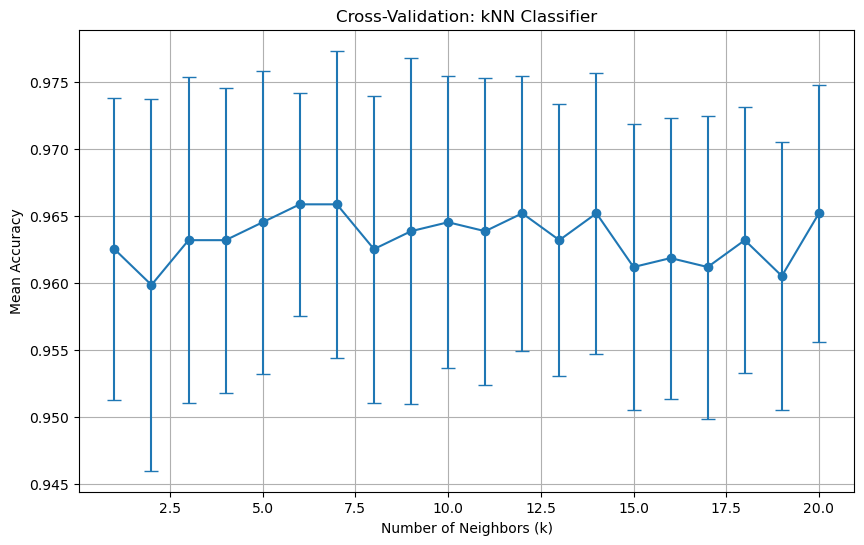

Best k: 6
Highest Cross-validation Accuracy for kNN: 0.9659


KNeighborsClassifier(n_neighbors=6)

In [9]:
# NOW PART ii

k_values = range(1, 21)

# Store results for kNN
results_knn = {'k': [], 'mean_accuracy': [], 'std_accuracy': []}

warnings.filterwarnings("ignore", category=FutureWarning)

# Cross-validation setup using the same X and y
for k in k_values:
    accuracy_scores = []
    
    # Perform cross-validation
    for train_index, test_index in kf.split(X):
        X_train_cv, X_test_cv = X[train_index], X[test_index]
        y_train_cv, y_test_cv = y[train_index], y[test_index]
        
        # Train kNN model
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_cv, y_train_cv)
        
        # Predict and calculate accuracy
        y_pred_cv = knn.predict(X_test_cv)
        accuracy_scores.append(accuracy_score(y_test_cv, y_pred_cv))
    
    # Store the mean and std of cross-validation accuracy for each k
    results_knn['k'].append(k)
    results_knn['mean_accuracy'].append(np.mean(accuracy_scores))
    results_knn['std_accuracy'].append(np.std(accuracy_scores))

# Convert to DataFrame for easy plotting
results_knn_df = pd.DataFrame(results_knn)

# Plotting the cross-validation results with error bars for kNN
plt.figure(figsize=(10, 6))
plt.errorbar(results_knn_df['k'], results_knn_df['mean_accuracy'], yerr=results_knn_df['std_accuracy'], marker='o', capsize=5)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validation: kNN Classifier')
plt.grid(True)
plt.show()

# Find the best k based on cross-validation accuracy
best_k_index = np.argmax(results_knn_df['mean_accuracy'])
best_k = results_knn_df.loc[best_k_index, 'k']
best_accuracy_knn = results_knn_df.loc[best_k_index, 'mean_accuracy']

print(f'Best k: {best_k}')
print(f'Highest Cross-validation Accuracy for kNN: {best_accuracy_knn:.4f}')

# Now train the final kNN model with the best k on the full data
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X, y)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
final_knn = KNeighborsClassifier(n_neighbors=6)
final_knn.fit(X_train, y_train)

# Calculate accuracy on the test set
test_accuracy_knn = final_knn.score(X_test, y_test)
print(f"Test Accuracy for kNN (k=6): {test_accuracy_knn:.4f}")

Test Accuracy for kNN (k=6): 0.9732


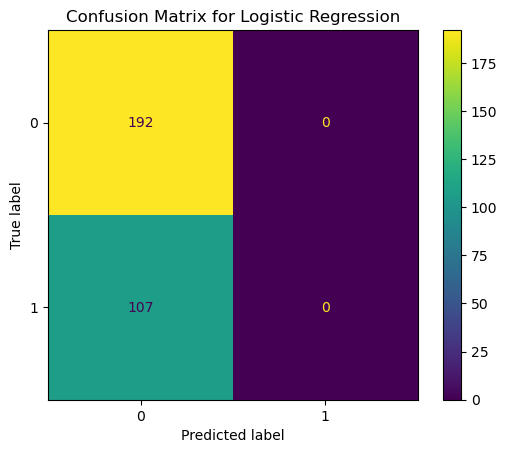

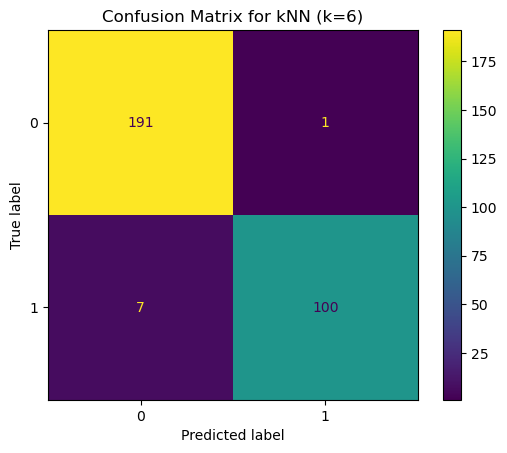

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Logistic Regression (Best model from part i.a)
best_degree = 1
best_C = 0.001
poly = PolynomialFeatures(degree=best_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

log_reg = LogisticRegression(penalty='l2', C=best_C, max_iter=10000)
log_reg.fit(X_poly_train, y_train)
y_log_reg_pred = log_reg.predict(X_poly_test)

# Calculate and display confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_log_reg_pred)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot()
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# 2. kNN Classifier with k=17
k = 6
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_knn_pred = knn.predict(X_test)

# Calculate and display confusion matrix for kNN
cm_knn = confusion_matrix(y_test, y_knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title(f'Confusion Matrix for kNN (k={k})')
plt.show()


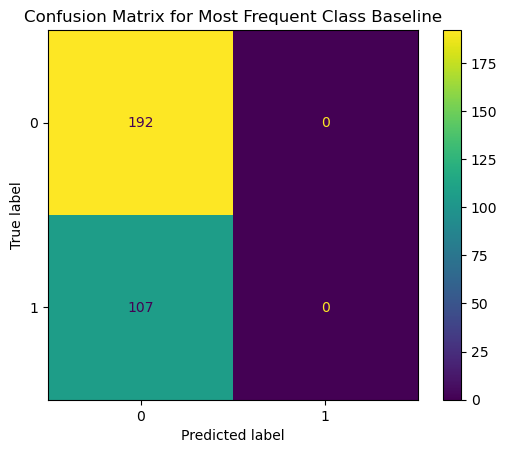

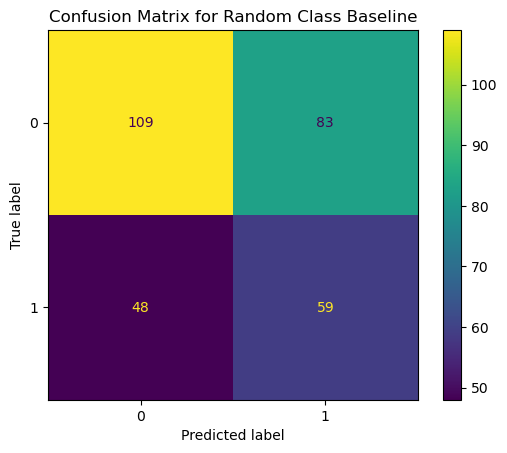

In [14]:
dummy_most_frequent = DummyClassifier(strategy="most_frequent")
dummy_most_frequent.fit(X_train, y_train)
y_dummy_mf_pred = dummy_most_frequent.predict(X_test)

# Calculate and display confusion matrix for most frequent class baseline
cm_dummy_mf = confusion_matrix(y_test, y_dummy_mf_pred)
disp_dummy_mf = ConfusionMatrixDisplay(confusion_matrix=cm_dummy_mf)
disp_dummy_mf.plot()
plt.title('Confusion Matrix for Most Frequent Class Baseline')
plt.show()

# Baseline 2: Classifier that makes random predictions
dummy_random = DummyClassifier(strategy="uniform")
dummy_random.fit(X_train, y_train)
y_dummy_random_pred = dummy_random.predict(X_test)

# Calculate and display confusion matrix for random baseline
cm_dummy_random = confusion_matrix(y_test, y_dummy_random_pred)
disp_dummy_random = ConfusionMatrixDisplay(confusion_matrix=cm_dummy_random)
disp_dummy_random.plot()
plt.title('Confusion Matrix for Random Class Baseline')
plt.show()

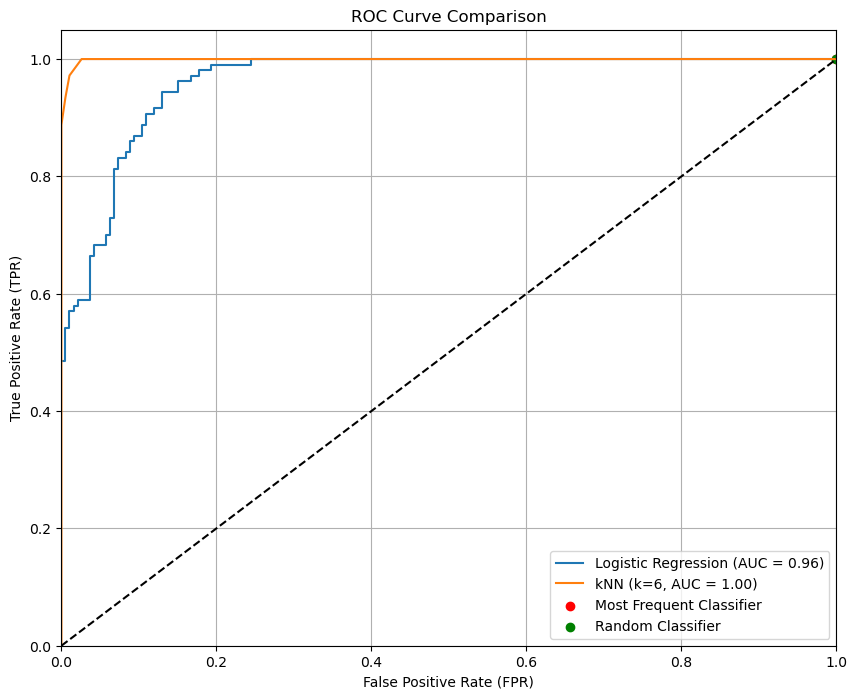

In [15]:
best_degree = 1
best_C = 0.001
poly = PolynomialFeatures(degree=best_degree)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

log_reg = LogisticRegression(penalty='l2', C=best_C, max_iter=10000)
log_reg.fit(X_poly_train, y_train)

# Predict probabilities for Logistic Regression
y_log_reg_probs = log_reg.predict_proba(X_poly_test)[:, 1]

# 2. kNN Classifier with k=17
k = 6
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predict probabilities for kNN
y_knn_probs = knn.predict_proba(X_test)[:, 1]

# 3. Baseline Classifiers
# Baseline 1: Classifier that always predicts the most frequent class
dummy_most_frequent = DummyClassifier(strategy="most_frequent")
dummy_most_frequent.fit(X_train, y_train)
y_dummy_mf_probs = dummy_most_frequent.predict_proba(X_test)[:, 1]

# Baseline 2: Classifier that makes random predictions
dummy_random = DummyClassifier(strategy="uniform")
dummy_random.fit(X_train, y_train)
y_dummy_random_probs = dummy_random.predict_proba(X_test)[:, 1]

# Plot ROC Curves
plt.figure(figsize=(10, 8))

# Logistic Regression ROC
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_log_reg_probs)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# kNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_probs)
roc_auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f'kNN (k={k}, AUC = {roc_auc_knn:.2f})')

# Baseline 1 (Most Frequent) ROC
fpr_dummy_mf, tpr_dummy_mf, _ = roc_curve(y_test, y_dummy_mf_probs)
plt.scatter(fpr_dummy_mf[1], tpr_dummy_mf[1], color='red', label='Most Frequent Classifier')

# Baseline 2 (Random) ROC
fpr_dummy_random, tpr_dummy_random, _ = roc_curve(y_test, y_dummy_random_probs)
plt.scatter(fpr_dummy_random[1], tpr_dummy_random[1], color='green', label='Random Classifier')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()